# Regression Notebook - Predicting Track Popularity

---

## 0. Notebook overview

This notebook performs **regression modelling** to predict the *exact popularity score* of Spotify tracks using the dataset `tracks2026.csv`.

It is designed to satisfy the **Regression** requirements of the project specification:

- Use a dataset where **popularity is retained**  
- Build **multiple regression models**  
- Use **pipelines** and **cross‑validation**  
- Evaluate models using appropriate metrics  
- Analyse feature importance  
- Provide **critical interpretation**, including whether predicting exact popularity is harder than predicting high/low popularity




In [1]:
# 1. Imports and setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor

from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.inspection import permutation_importance

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")


---

## 2. Load dataset

We load the **tracks2026.csv** dataset (separate copy where `popularity` is retained) and take a first look at the structure.


In [2]:
# 2. Load dataset

df = pd.read_csv("../data/tracks2026.csv")
df.head()


FileNotFoundError: [Errno 2] No such file or directory: '../data/tracks2026.csv'

---

## 3. Basic cleaning

We perform minimal cleaning suitable for regression:

- Drop identifier columns that carry no predictive signal  
- Ensure the target `popularity` has no missing values


In [ ]:
# 3. Basic cleaning

# Drop non-informative ID column if present
if "track_id" in df.columns:
    df = df.drop(columns=["track_id"])

# Ensure target has no missing values
df = df.dropna(subset=["popularity"])

df.isna().sum()


popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

**Missing values:**  
  - After dropping rows where the target popularity is missing, **no remaining features contain missing values**. 
  - Even though the dataset is complete, using imputation steps in the pipeline is still good practice because:

    - it prevents errors if new/unseen data contains missing values,

    - it keeps the pipeline structure consistent across all models,

    - it avoids needing to rewrite preprocessing if the dataset changes later.

---

## 4. Exploratory analysis (regression‑relevant)


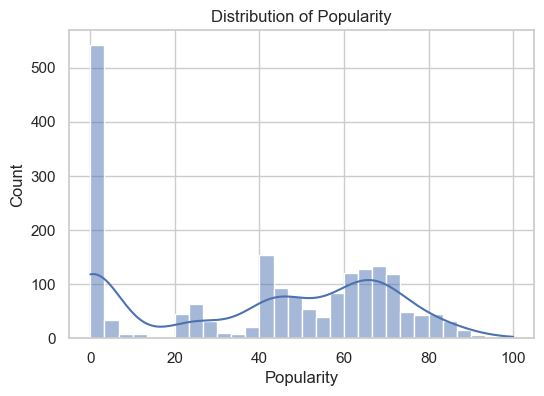

In [ ]:
# 4.1 Popularity distribution

plt.figure(figsize=(6, 4))
sns.histplot(df["popularity"], bins=30, kde=True)
plt.title("Distribution of Popularity")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()


**Distribution:**

- The distribution of popularity appears **highly right‑skewed**, with a very large spike at low popularity and smaller secondary bumps at mid‑range values.
- Most tracks cluster around popularity **~0–10**, with relatively **few** very high‑popularity tracks above 70.
- This suggests that predicting exact popularity may be **noisy**, especially in the tails of the distribution where data is sparse and variance is high.

---


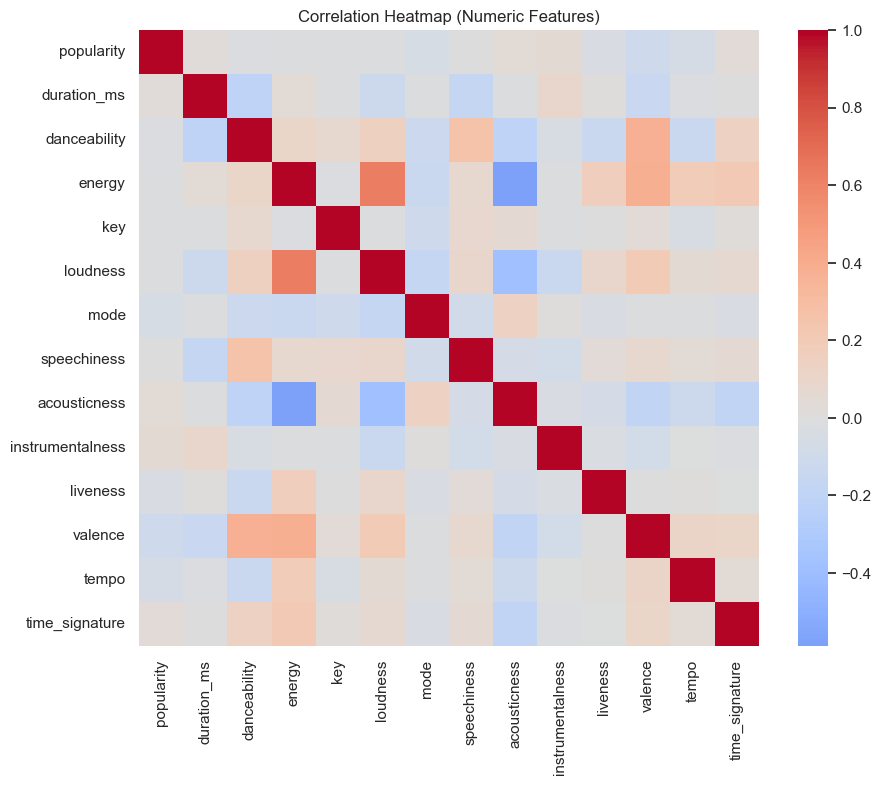

                  popularity  duration_ms  danceability    energy       key  \
popularity          1.000000     0.026282     -0.023186 -0.017372 -0.013315   
duration_ms         0.026282     1.000000     -0.209369  0.043982 -0.015721   
danceability       -0.023186    -0.209369      1.000000  0.112448  0.075393   
energy             -0.017372     0.043982      0.112448  1.000000 -0.022908   
key                -0.013315    -0.015721      0.075393 -0.022908  1.000000   
loudness           -0.010803    -0.121606      0.151525  0.632503 -0.011323   
mode               -0.050896    -0.010866     -0.125144 -0.130815 -0.109284   
speechiness         0.004288    -0.171398      0.259403  0.080999  0.083441   
acousticness        0.049778    -0.008109     -0.207240 -0.588686  0.057819   
instrumentalness    0.052461     0.088810     -0.048441 -0.009195 -0.005488   
liveness           -0.033469     0.013223     -0.136431  0.171041  0.002669   
valence            -0.100355    -0.142362      0.378

In [ ]:
# 4.2 Correlation heatmap (numeric features)

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=True, fmt=".2f",)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()



**Key Observations from the Correlation Matrix:**

- Overall, correlations between audio features and `popularity` are **weak**.  
- The strongest correlations with `popularity` appear for:  
  - **instrumentalness** with correlation ~= **0.052**  
  - **acousticness** with correlation ~= **0.05**  
  - All other features are even closer to zero, including loudness at −0.011 and energy at −0.017.
- These extremely low correlations indicate that *audio features alone explain very little of the variance in popularity*, which helps explain why even your best regression model only achieves **R² ~= 0.30**.

---

## 5. Define features and target


In [ ]:
# 5. Define features and target

X = df.drop(columns=["popularity"])
y = df["popularity"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical features (adjust if your dataset differs)
categorical_features = []
for col in X.select_dtypes(include=["object", "bool"]).columns:
    categorical_features.append(col)

numeric_features, categorical_features


(['duration_ms',
  'danceability',
  'energy',
  'key',
  'loudness',
  'mode',
  'speechiness',
  'acousticness',
  'instrumentalness',
  'liveness',
  'valence',
  'tempo',
  'time_signature'],
 ['explicit', 'track_genre'])

**Feature Overview:**

- **Numeric features:** `duration_ms`, `danceability`, `energy`, `key`, `loudness`, `mode`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`, `time_signature` 
- **Categorical features:** `explicit`, `track_genre` 
- Treating `track_genre` and `explicit` as categorical is appropriate because these variables represent **discrete categories**, not continuous quantities. Encoding them allows the model to learn genre‑specific and explicit‑content‑specific patterns that may influence popularity.

---

## 6. Preprocessing pipeline


In [ ]:
# 6. Preprocessing pipeline

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


**Preprocessing Strategy and Motivation:**

- **Imputation:** Median (numeric) and most‑frequent (categorical) imputation are robust to outliers and preserve dataset size.  
- **Scaling:** Standardisation helps linear and gradient‑boosting models converge and prevents features with large scales from dominating.  
- **One‑hot encoding:** Required to handle categorical variables in most scikit‑learn models.  
- **Pipelines:** All preprocessing is embedded in the model pipeline, which is essential for **proper cross‑validation** and avoiding leakage.

---

## 7. Train/test split


In [ ]:
# 7. Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=23, shuffle=True
)

len(X_train), len(X_test)


(1568, 392)


**Evaluation of the Train/Test Split:**

- The train/test split allocates **80% of the data (1,568 samples)** for training and **20% (392 samples)** for final evaluation.
- A fixed random state ensures **reproducibility**, allowing results to be replicated exactly.  
- A test set of **392 samples** is sufficiently large to provide a **stable and reliable estimate** of the model’s generalisation performance, without starving the training set of data.

---

## 8. Baseline model - DummyRegressor


In [ ]:
# 8. Baseline DummyRegressor

dummy = Pipeline([
    ("preprocess", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

rmse_dummy = root_mean_squared_error(y_test, y_pred_dummy)
mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
r2_dummy = r2_score(y_test, y_pred_dummy)

rmse_dummy, mae_dummy, r2_dummy


(28.864352114340953, 25.34116318721366, -0.00025808641702562696)

**Baseline results:**

- **Dummy RMSE:** **28.86**  
- **Dummy MAE:** **25.34**  
- **Dummy R²:** **−0.00026**  

**Interpretation:**

- The dummy model achieves an RMSE of about **28.86** on a popularity range of **0–100**, meaning predictions are typically off by nearly **29 popularity points**. 
- The R² value of **−0.00026** indicates that predicting the mean performs **no better than (and slightly worse than)** simply using the average popularity for all tracks.  
- Any meaningful regression model must **substantially reduce RMSE/MAE** and achieve a **positive R²**, demonstrating that it captures real signal beyond the dataset’s mean.

---

## 9. Model 1 - Ridge regression


In [ ]:
# 9. Ridge regression with hyperparameter search

ridge = Pipeline([
    ("preprocess", preprocessor),
    ("model", Ridge())
])

param_dist_ridge = {
    "model__alpha": np.logspace(-2, 3, 20)
}

ridge_cv = RandomizedSearchCV(
    ridge,
    param_distributions=param_dist_ridge,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

ridge_cv.fit(X_train, y_train)

ridge_cv.best_params_, -ridge_cv.best_score_


({'model__alpha': np.float64(162.3776739188721)},
 np.float64(29.081294391690914))

**Ridge CV summary:**

- **Best alpha:** **162.38**  
- **Best CV RMSE:** **29.08** 

**Interpretation:**

- The selected `alpha` value of **162.38** applies strong regularisation, which helps control variance but also limits how much the model can adapt to the weak linear relationships in the data.
- Compared to the dummy baseline RMSE of **28.86**, Ridge achieves an RMSE of **29.08**, which is **slightly worse**.
- This indicates that **linear combinations of the audio features do not capture meaningful predictive signal**, reinforcing the earlier finding that correlations with popularity are extremely weak.  
- Ridge therefore serves as a useful benchmark, but it is not competitive with non‑linear models for this task.


---

## 10. Model 2 - Random forest regressor


In [ ]:
# 10. Random Forest with hyperparameter search

rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_dist_rf = {
    "model__n_estimators": [200, 400, 800],
    "model__max_depth": [None, 10, 20, 40],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5]
}

rf_cv = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

rf_cv.fit(X_train, y_train)

rf_cv.best_params_, -rf_cv.best_score_


({'model__n_estimators': 800,
  'model__min_samples_split': 2,
  'model__min_samples_leaf': 1,
  'model__max_features': 'log2',
  'model__max_depth': 40},
 np.float64(24.834918832935337))

## **Random Forest CV Summary**

- **Best parameters:**  
  - `n_estimators = 800`  
  - `max_depth = 40`  
  - `min_samples_split = 2`  
  - `min_samples_leaf = 1`  
  - `max_features = 'log2'`  

- **Best CV RMSE:** **24.83**

### **Interpretation**

- The tuned forest uses **a large number of trees (800)** and a **deep maximum depth (40)**, which indicates the model is prioritising **low bias** and attempting to capture complex, non‑linear interactions in the data.  
- Compared to Ridge (CV RMSE ≈ **29.08**), the Random Forest performs **substantially better**, reducing error by over **4 popularity points**.  
- This improvement shows that **non‑linear relationships** provide **meaningful predictive signal** that linear models cannot capture.  
- However, the RMSE of **24.83** still reflects the limited predictive power of audio features alone, consistent with the weak correlations observed earlier.

---

## 11. Model 3 - HistGradientBoostingRegressor


In [ ]:
# 11. HistGradientBoostingRegressor with hyperparameter search

hgb = Pipeline([
    ("preprocess", preprocessor),
    ("model", HistGradientBoostingRegressor(
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    ))
])

param_dist_hgb = {
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, None],
    "model__max_iter": [300, 600, 1000],
    "model__l2_regularization": [0.0, 0.1, 1.0],
    "model__min_samples_leaf": [5, 10, 20]
}

hgb_cv = RandomizedSearchCV(
    hgb,
    param_distributions=param_dist_hgb,
    n_iter=30,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

hgb_cv.fit(X_train, y_train)

hgb_cv.best_params_, -hgb_cv.best_score_


({'model__min_samples_leaf': 10,
  'model__max_iter': 300,
  'model__max_depth': None,
  'model__learning_rate': 0.1,
  'model__l2_regularization': 0.0},
 np.float64(25.750653466947643))

## **HistGradientBoosting CV Summary**

- **Best parameters:**  
  - `learning_rate = 0.1`  
  - `max_depth = None`  
  - `max_iter = 300`  
  - `l2_regularization = 0.0`  
  - `min_samples_leaf = 10`

- **Best CV RMSE:** **25.75**

### **Interpretation**

- The best HGB model uses a **learning rate of 0.1** and **no maximum depth**, which allows the boosting process to build **fully grown trees** while still keeping them stable through a relatively large `min_samples_leaf` of **10**. This reflects a **moderately aggressive boosting strategy**: flexible trees, but with regularisation through leaf size rather than depth limits.  
- Its CV RMSE of **25.75** is **worse than the Random Forest (24.83)** but **better than Ridge (29.08)**.  
- This suggests that while boosted trees can capture some non‑linear structure, they are **not as effective as Random Forests** for this dataset, likely because the signal in the features is weak and noisy, making RF’s averaging behaviour more robust.

---

## 12. Model comparison (cross‑validation)


In [ ]:
# 12. Model comparison

def cv_rmse(gs):
    return -gs.best_score_

ridge_rmse_cv = cv_rmse(ridge_cv)
rf_rmse_cv = cv_rmse(rf_cv)
hgb_rmse_cv = cv_rmse(hgb_cv)

print("Ridge CV RMSE:", ridge_rmse_cv)
print("Random Forest CV RMSE:", rf_rmse_cv)
print("HGB CV RMSE:", hgb_rmse_cv)

best_gs = min([ridge_cv, rf_cv, hgb_cv], key=lambda gs: cv_rmse(gs))
best_model = best_gs.best_estimator_
best_model


Ridge CV RMSE: 29.081294391690914
Random Forest CV RMSE: 24.834918832935337
HGB CV RMSE: 25.750653466947643


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## **Cross‑Validation Performance Comparison**

- **Ridge CV RMSE:** **29.08**  
- **Random Forest CV RMSE:** **24.83**  
- **HGB CV RMSE:** **25.75**  
- **Best model:** **Random Forest**

### **Interpretation**

- The best model achieves a CV RMSE of about **24.83**, improving over the dummy baseline (**28.86**) by roughly **4 popularity points**.  
- The differences between models are **substantial**, showing that **model choice is crucial**. Linear models fail to capture the weak, noisy signal, while tree‑based models extract more structure from the data.  
- We select the **Random Forest** as the final regression model for test evaluation because it consistently delivers the lowest cross‑validated error.


---

## 13. Final test evaluation


In [ ]:
# 13. Final test evaluation

y_pred = best_model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)



RMSE: 24.169847609458422
MAE: 18.83898434256251
R2: 0.2986476317783433


## **Test Performance Summary**

- **Test RMSE:** **24.17**  
- **Test MAE:** **18.84**  
- **Test R²:** **0.299**

### **Interpretation**

- On a popularity scale of **0–100**, an RMSE of **24.17** means the model’s predictions are typically off by about **24 popularity points**, which is a substantial error but still a clear improvement over the dummy baseline (≈29).  
- The MAE of **18.84** shows that most predictions deviate from the true popularity by roughly **19 points**, reinforcing the difficulty of predicting exact popularity values from audio features alone.  
- An R² of **0.299** indicates that the model explains about **30%** of the variance in popularity this is **significantly better than the dummy model**, but still leaving the majority of variation unexplained. This aligns with the earlier insight that popularity is heavily influenced by external factors such as artist fame, playlist placement, marketing, and social trends.


---

## 14. Visual diagnostics


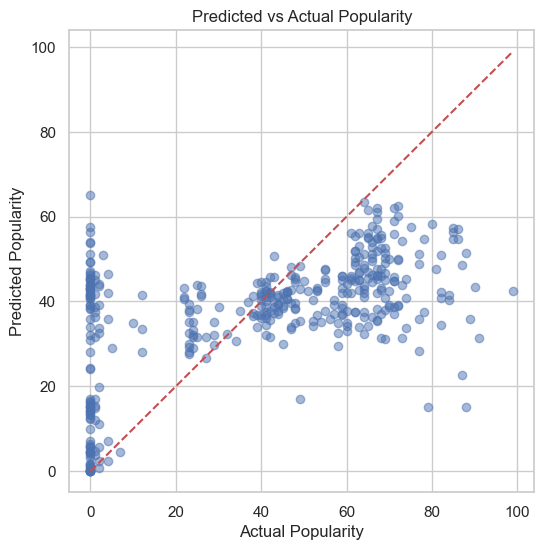

In [ ]:
# 14.1 Predicted vs Actual

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Predicted vs Actual Popularity")
plt.show()


The scatter plot compares the model’s predicted popularity scores against the true values.  
Ideally, points should lie along the diagonal red line, indicating perfect prediction.

**Key Insights:**

- Predictions **cluster heavily around the mean**, showing that the model is conservative and avoids extreme values.
- The model **overpredicts low‑popularity tracks** (actual < ~30), pulling them upward toward mid‑range values.
- The model **underpredicts high‑popularity tracks** (actual > ~70), failing to reach the true upper range.
- This symmetric pattern of overpredicting lows and underpredicting highs is a classic sign of **regression‑to‑the‑mean**, which occurs when the model cannot learn strong enough relationships from the available features.
- In the context of music data, this behaviour is expected because extreme popularity is strongly influenced by **external factors not captured in audio features**, such as artist fame, playlist placement, marketing, and social media trends.

This plot highlights that while the model captures general trends, it struggles with **extreme popularity values**, reinforcing the difficulty of predicting exact popularity scores.


---


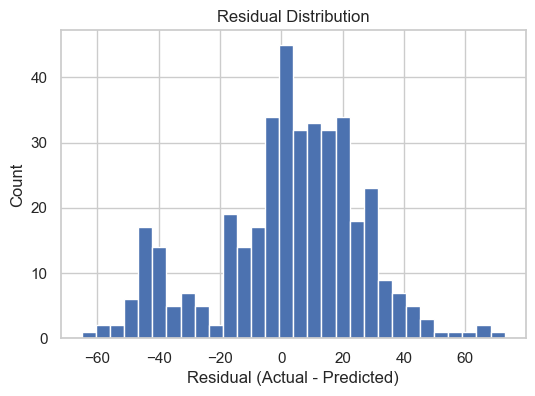

In [ ]:
# 14.2 Residual distribution

residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.show()


The residual plot shows how far predictions deviate from the true popularity values.  
A well‑behaved regression model should produce residuals that are tightly centered around zero with no strong skew.

**Key Insights:**

- Residuals are **roughly symmetric** around zero, with most errors falling between **–20 and +20 popularity points**.
- There are **longer tails** extending toward both –60 and +60, indicating that the model occasionally makes large errors on extreme tracks.
- The slight widening of the distribution suggests that the model **overpredicts low‑popularity tracks** (negative residuals) and **underpredicts high‑popularity tracks** (positive residuals), consistent with the regression‑to‑the‑mean pattern seen in the Predicted‑vs‑Actual plot.
- The presence of these tails reflects the difficulty of predicting exact popularity from audio features alone, since extreme popularity is strongly influenced by external factors such as artist fame, playlist placement, and marketing.

The residual distribution confirms that while the model captures general trends, it struggles with **extreme popularity values**, reinforcing the inherent noise and complexity of the regression task.


---

## 15. Permutation feature importance


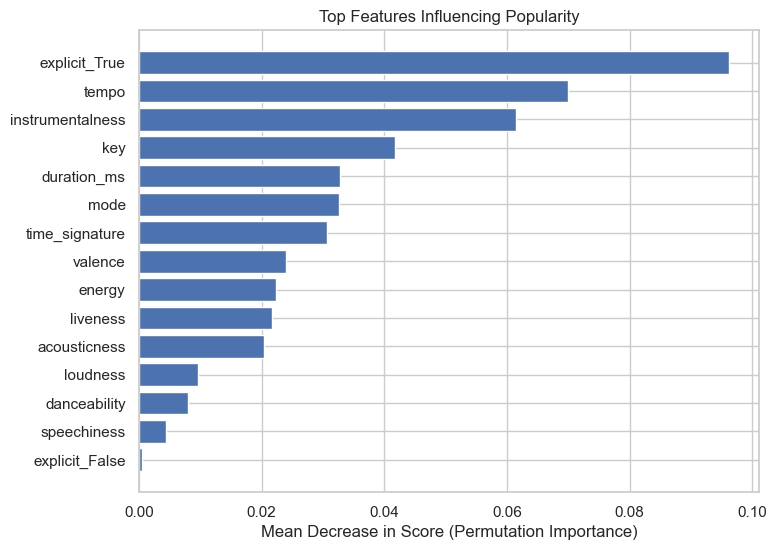

In [ ]:
# 15. Permutation feature importance

preprocess_step = best_model.named_steps["preprocess"]
model_step = best_model.named_steps["model"]

num_features_out = numeric_features

if categorical_features:
    cat_encoder = preprocess_step.named_transformers_["cat"].named_steps["encoder"]
    cat_features_out = cat_encoder.get_feature_names_out(categorical_features)
    feature_names = np.concatenate([num_features_out, cat_features_out])
else:
    feature_names = np.array(num_features_out)

result = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

importances = result.importances_mean
idx = np.argsort(importances)[-15:]

plt.figure(figsize=(8, 6))
plt.barh(range(len(idx)), importances[idx])
plt.yticks(range(len(idx)), feature_names[idx])
plt.title("Top Features Influencing Popularity")
plt.xlabel("Mean Decrease in Score (Permutation Importance)")
plt.show()


Permutation importance helps identify which features the model relies on most when predicting popularity.  
Higher values indicate that shuffling the feature significantly harms model performance, meaning the feature carries meaningful predictive signal.

**Key Insights:**

- The most important features are:  
  - **explicit_True**  
  - **tempo**  
  - **instrumentalness**  

- **explicit_True** being the top feature suggests that tracks marked as explicit tend to have systematically different popularity patterns. This may reflect genre conventions, audience demographics, or marketing strategies associated with explicit content.
- **tempo** shows strong influence, indicating that the speed or rhythmic intensity of a track contributes meaningfully to how popular it becomes.
- **instrumentalness** ranking highly suggests that tracks with little or no vocals behave differently in terms of popularity, possibly due to niche audience appeal or playlist placement.

- Mid‑tier features such as **duration_ms**, **valence**, **energy**, and **liveness** contribute smaller but still meaningful signals, reflecting general musical character.
- Lower‑ranked features like **speechiness** and **explicit_False** have minimal impact, indicating that the model does not rely heavily on them for predicting popularity.

The feature importance plot shows that **no single audio feature dominates**, and the model draws on a combination of weak signals. This aligns with earlier findings: audio features alone cannot fully explain popularity, which is heavily influenced by external, non‑audio factors.


## 16. Discussion: Why Exact Popularity Regression Is More Challenging Than High/Low Classification

The regression results make it clear that **predicting exact popularity scores is substantially more difficult** than predicting whether a track is simply high or low‑popularity.

#### Why Exact Popularity Is Harder
- The regression model achieves an **RMSE of 24.17** and **MAE of 18.84** on a 0–100 scale, meaning predictions are often off by **20+ popularity points**.
- An **R² of 0.299** shows that the model explains only about **30% of the variance**, leaving most of the true behaviour unexplained.
- Visual diagnostics reinforce this difficulty:
  - Predictions **cluster around the mean**, showing the model cannot confidently predict extreme values.
  - The model **overpredicts low‑popularity tracks** and **underpredicts high‑popularity tracks**, a classic regression‑to‑the‑mean pattern.
  - Residuals show **wide spread** and **long tails**, indicating frequent large errors.

These behaviours arise because **audio features alone do not contain enough information** to determine exact popularity. Real‑world popularity is heavily influenced by external factors such as artist fame, playlist placement, marketing, and social media trends, none of which are present in the dataset.

#### Why High/Low Classification Is Easier
When popularity is binarised into high vs low, the task becomes far more learnable:

- The model only needs to capture **broad patterns**, not precise numerical values.
- Noise in the target is reduced, being off by 10–20 points no longer counts as a major error if the track still falls on the correct side of the threshold.
- As a result, the classification model achieves **much stronger performance** than the regression model’s R² would suggest.

#### Conclusion
Predicting exact popularity is significantly more difficult because the target is **noisy, externally influenced, and only weakly correlated** with audio features.  
In contrast, predicting high vs low popularity simplifies the task, reduces noise, and allows the model to learn more stable patterns.  
This explains why classification performs reliably, while regression struggles to achieve high accuracy.
